In [4]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 2288              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.13.0+cpu
MY_SEED         : 2288
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요.
: 샘플수는 1797, 픽셀수는 64이다.

2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.
: 입력 노드는 64개(픽셀수=d)이고, 출력 노드는 10개(클래스수=Task에 의존)이다.

3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.
: 달라지지 않는다. 원본데이터의 로드는 MY_SEED의 영향을 받지 않는다.

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.

클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


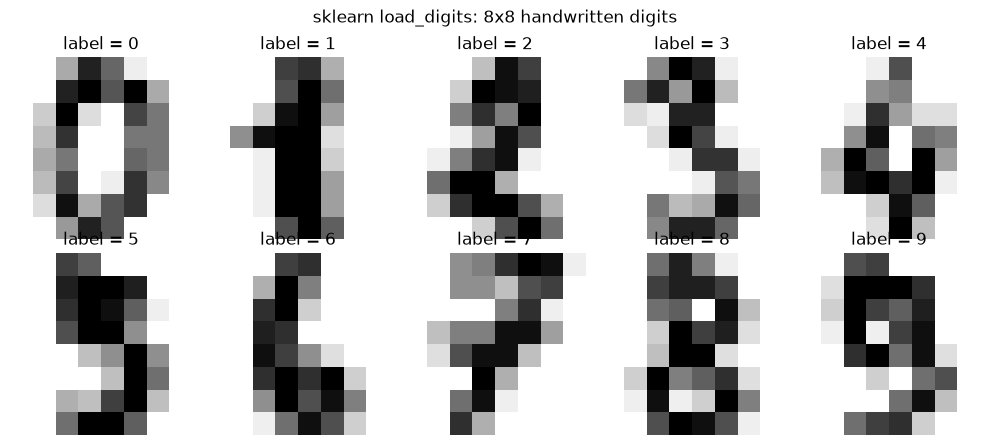


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): 0.0000 / 0.9682
표준화 후 test  평균/표준편차 (전체 픽셀 기준): 0.0030 / 0.9411   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [5]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?
: train / val / test 각각 (1078,64), (359, 64), (360, 64)로 샘플이 배정되었다. 클래스별 개수를 확인해본 결과 1주차 Framingham의 클래스처럼 불균형하지 않다. 모든 클래스가 174~183개의 샘플을 보유하고 있기 때문에 무조건 한 클래스로만 찍을 경우 10%의 정확도를 갖게 된다.

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.
: X_test_s는 표준화를 진행할때 train 데이터의 값을 이용하여 표준화를 하였기 때문에 평균이 정확히 0이 나오지 않았다. 만약 test에도 따로 fit처리를 하게 된다면 모델의 학습과정에서 train데이터만 학습되는 것이 아니라 test 데이터도 학습에 포함되어 데이터 누수가 발생하기 때문에 그렇게 하면 안된다.

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)
: Train 데이터로 모델을 학습하고, validation 데이터로 과적합이 시작되기 전의 최적의 학습 종료 시점(Early Stopping)을 결정하며, Test 데이터로 최종 모델의 성능을 평가하기 위해 세 종류의 데이터로 분리가 필요하다.

In [6]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    #layers.append(nn.Softmax(dim=1))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum = 0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

          

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x000002047C36E340>
  <function evaluate at 0x000002047C36E160>
  <function train_model at 0x000002047C2A89A0>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


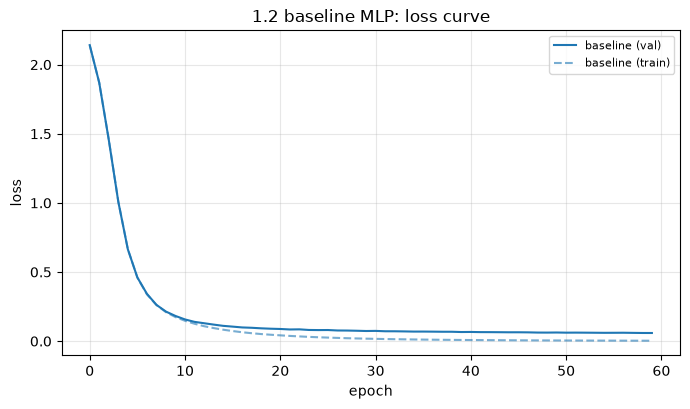

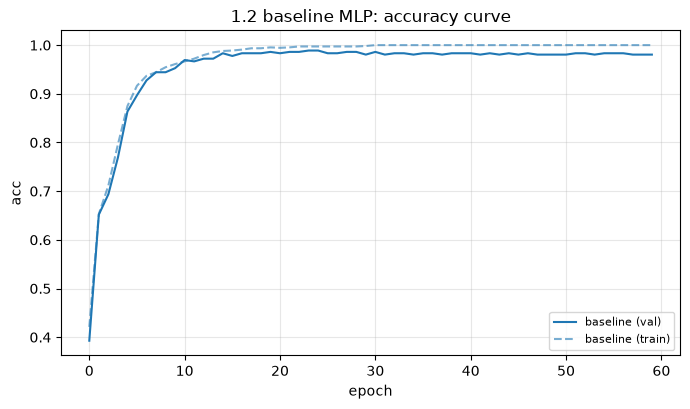


[최종] test loss = 0.0827 | test accuracy = 0.9750
val_loss 최저 epoch = 60 (val_loss = 0.0590)
마지막 epoch 의 train_loss = 0.0031 / val_loss = 0.0590
train_acc = 1.0000 / val_acc = 0.9805


In [7]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base["val_loss"])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)
: 이 모델의 파라미터 수는 6570개로 직접 계산한 값과 일치한다.

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?
: test accuracy는 0.9750으로 무조건 한 클래스만 찍을경우에 비해 약 9배 정도 높은 정확도를 갖는다.

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.
: 대략 60 epoch에서 부터 val loss값의 감소가 더뎌지기 시작했고, 그때의 val loss값은 0.0590, train loss 값은 0.0031이다. train loss값은 epoch가 증가할수록 계속 감소하고, val loss는 처음에는 감소하지만 어느 시점 이후로는 다시 증가하게된다. epoch 60에서 train loss값과 val loss값이 사이의 차이가 점점 커지게 되었고 이는 최적 학습 지점을 지난 과적합 구간일 수 있다.

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.
: PyTorch는 gradient를 자동으로 초기화하지 않고 계속 누적한다. 따라서 train loss가 초반에는 감소하나 이후 곡선이 요동치며 상승하는 모양이 그려진다. 또한 accuracy 그래프도 매끄럽게 상승하지 않고 요동치면서 상승과 하강을 반복한다.

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)
: train accuracy가 1에서 0.9954로 낮아지게 되었다. `nn.CrossEntropyLoss`는 내부적으로 모든 값을 0~1사이로 만드는 softmax에 해당하는 연산을 포함하고 있으므로 출력층에 softmax를 추가하면 이미 0~1사이로 압축된 값을 다시 CrossEntropyLoss에 전달하게 되어 학습 효율이 떨어질 수 있다.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.57e-07 3.91e-07 2.88e-06 1.85e-05 1.27e-04 8.79e-04 6.87e-03 4.96e-02 3.55e-01
[ReLU]     4.70e-04 2.66e-04 2.65e-04 3.37e-04 4.71e-04 8.50e-04 2.43e-03 8.49e-03 1.95e-02

Sigmoid: 마지막층 / 첫번째층 = 2.266e+06 배
ReLU   : 마지막층 / 첫번째층 = 4.147e+01 배


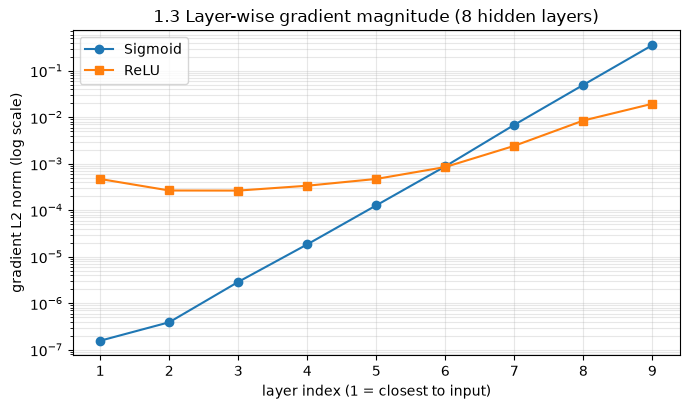

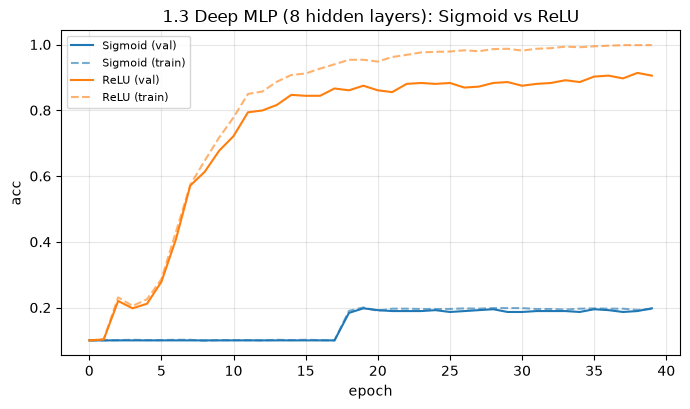


[Sigmoid 8층] 최종 train_acc = 0.1957 / val_acc = 0.1978
[ReLU    8층] 최종 train_acc = 0.9981 / val_acc = 0.9053
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9805


In [8]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.
: Sigmoid 네트워크의 첫 번째 층은 1.57e-07, 마지막 층은 3.55e-01이고, 2.266e+06 배 차이가 난다. ReLU는 4.147e+01 배 차이가 난다. Sigmoid에 비해 ReLU는 첫 번째 층과 마지막 층의 차이가 크지 않으므로 gradient가 앞쪽 층까지 잘 전달되어 Vanishing Gradient 현상이 완화된것을 알 수 있다.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
: 역전파에서는 chain rule에 의해 각 층의 gradient가 이전 층으로 전달될때마다 도함수가 계속 곱해지게 된다. sigmoid의 도함수는 층을 하나 거칠 때마다 최대 0.25 이하의 값이 계속 곱해지므로 은닉층이 많아질수록 gradient가 기하급수적으로 감소하여 입력층에 가까운 가중치의 gradient가 거의 0에 가깝게 된다. 따라서 앞쪽 층의 가중치가 거의 업데이트되지 않아 vanishing gradient가 발생한다. 반면 ReLU의 도함수는 양수 구간에서 1, 음수구간에서는 0으로 양수 영역에서는 층을 지나도 gradient가 계속 1을 곱하는 것과 같아 크게 감소하지 않는다. 그결과 gradient가 입력층까지 비교적 잘 전달되어 앞쪽 층의 가중치도 충분히 업데이트 될 수 있으며 sigmoid 보다 vanishing gradient가 훨씬 덜 발생하게 된다.

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)
: Sigmoid의 8층 최종 train accuracy는 0.1957이고, ReLU의 train accuracy는 0.9981이다. 과적합은 train 데이터에 너무 fit하게 학습하여 train 데이터에서는 성능이 좋지만, val이나 test에서는 안좋게 나오는 반면 sigmoid의 문제는 train에서 잘하는 것이 아니라 vanishing gradient로 인해 학습 자체가 제대로 이루어지지 않고 실패한 것에 해당한다.

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)
: 층이 4배로 늘었지만 val_acc는 0.08정도 작아졌다. ReLU 모델이라고 하더라도 층이 깊어질수록 정보의 손실은 필연적이기 때문에 성능이 오히려 안좋아졌다고 생각한다.

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.
: Sigmoid의 backpropagation에서 chain rule에 의해 각 층의 gradiet가 이전 층으로 전달 될때 마다 도함수가 곱해지는데 sigmoid의 도함수는 최대값이 0.25이므로 층을 거듭할 수록 gradient 값이 작아지게 되어 val_acc가 0.1978와 같이 성능이 나쁘게 나온다. 따라서 가중치가 거의 업데이트 되지 않는 vanishing gradient가 발생한다. 이를 해결하기 위해서는 sigmoid 함수 대신 포화되지 않는(Non-saturating) 활성화 함수를 사용한다. 대표적으로는 ReLU, LeakyReLU, ELU, GELU가 존재한다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


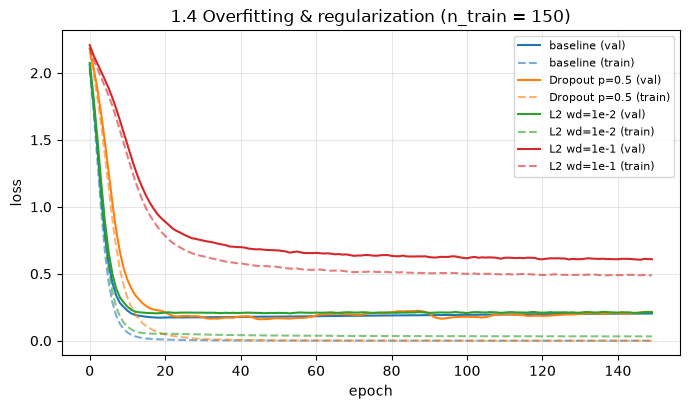

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0002    0.2032  0.2030     1.0000   0.9526       20       0.9526
Dropout p=0.5        0.0001    0.2154  0.2153     1.0000   0.9610       46       0.9666
L2 wd=1e-2           0.0323    0.2125  0.1802     1.0000   0.9526       54       0.9610
L2 wd=1e-1           0.4886    0.6091  0.1205     0.9800   0.9276      147       0.9387

[Early Stopping] baseline 은 epoch 20 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 130 epoch 를 낭비)


In [9]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256,256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.
: `train_loss`는 0.0002, `train_acc`는 1, `val_loss - train_loss`는 0.2030이다. train_loss가 0에 가깝고 acc는 1이라 train 데이터에는 모델이 적합하지만 val_loss와 train_loss의 gap이 0.2030으로 크게 나왔으므로 훈련오차는 줄지만 일반화 성능은 상대적으로 떨어지는 과적합이 발생했다고 볼 수 있다.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.
: epoch 20에서 val_loss가 최소였고, 전체 150 epoch 중 13.33% 지점이다. Early stopping을 적용했다면 20 epoch에서 학습을 종료하고도 가장 좋은 일반화 성능을 얻을 수 있었으며 이후 130 epoch는 불필요한 학습이었다. 또한 Early stopping은 모델의 구조를 변경하거나 새로운 파라미터를 추가하지 않고도 단순히 적절한 시점에서 학습을 멈추기만 하면 되므로 '공짜에 가까운 규제'라고 할 수 있다.

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)
: Dropout p=0.5의 결과 train_loss는 0.0001, val_loss는 0.2154, gap은 0.2153, train_acc는 1.0000, val_acc는 0.9610, best_ep는 46, best_val_acc는 0.9666이다. 최종 val_loss는 baseline보다 더 커져서 나빠졌지만 best_val_acc는 baseline보다 더 높게 나타났다. acc는 맞힌 샘플의 개수를 평가하는 반면, loss는 각 예측의 확신 정도를 반영한다. 즉, Dropout 모델은 baseline보다 더 많은 샘플을 맞히기는 했으나, 틀린샘플에 대해서는 지나치게 높은 확신을 보이는 등의 문제로 인해 두 지표가 서로 다른 방향을 보였을 수 있다.

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.
: L2 강도를 10배로 키웠더니 train_acc와 val_acc가 키우기 전보다 각각 0.02, 0.025 만큼 줄어들었다. 규제를 세게 걸면 모델의 학습 능력 자체를 지나치게 제한하게 되기 때문에 train 데이터 조차도 충분히 맞추지 못학 되고 그 결과 train_acc, val_acc가 낮아질 수 있다. 따라서 이는 과소적합에 해당하고 규제는 세게 건다고 해서 무조건적으로 좋지 않다.

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)
: validation accuracy 관점에서 보면 `Dropout p=0.5`가 가장 좋은 조건에 해당한다. baseline 조건에서 보면 모델은 train 데이터에 대한 정확도는 높지만, val_acc는 상대적으로 떨어지는 편이다. 이는 과적합에 해당한다고 볼 수 있고 따라서 과적합을 제한할 수 있는 규제나 기법을 사용하여야한다. dropout의 경우 train loss도 줄어들고, val_acc는 증가하였으며 baseline 조건보다 과적합이 완화되고 성능이 더 개선되었음을 알 수 있다. 반면 L2 규제의 경우는 train loss가 심하게 증가하였으며 val_acc가 떨어지거나 변화가 없었고, train_acc도 떨어지는 경우가 있었다.

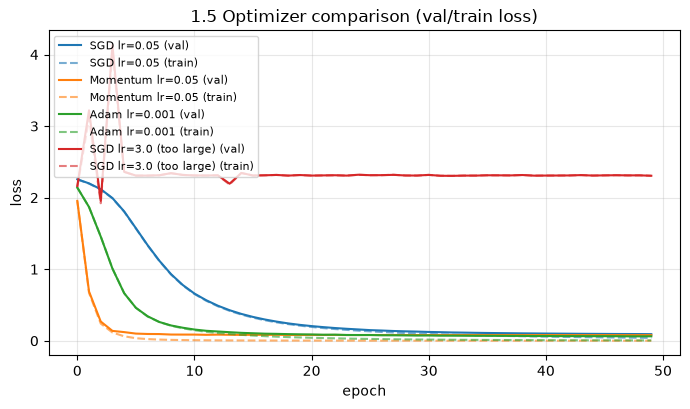

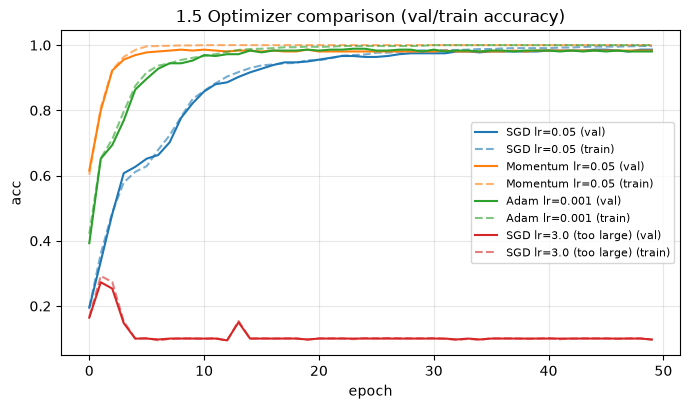

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2569            0.0403         0.9861        0.9861               14
Momentum lr=0.05           1.9550            0.0008         0.9833        0.9861                3
Adam lr=0.001              2.1412            0.0049         0.9805        0.9889                7
SGD lr=3.0 (too large)       2.1632            2.3061         0.0975        0.2730             None


In [10]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64, 32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.
: SGD(0.05)는 14, SGD(3.0)은 None, Momentum은 3, Adam은 7이다. Momentum의 경우 업데이트를 할때 현재 gradient + 과거 gradient를 하여서 방향이 자주 바뀌는 축은 서로 상쇄돼서 지그재그 움직임이 완화되고, 일관된 축은 가속되어 안장점을 빠르게 탈출할 수 있다. 따라서 Momentum이 순수 SGD보다 val_acc 90%에 더 이른 epoch에서 도달하게 된다.

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
: 성능에서는 거의 차이가 존재하지 않는다. Momentum은 수렴이 빠른 반면 오히려 순수 SGD보다 final val_acc는 조금 더 낮은 성능을 보여, '수렴이 빠르다'와 '최종 성능이 좋다'는 같은 말이 아님을 알 수 있다.

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)
: val_loss 값은 2.1632으로, learning rate가 너무 커서 학습이 제대로 되지 않아 모델이 거의 무작위 추측 수준에 있다는 것을 알 수 있다. 10개 클래스에 균등확률을 준다면 p=0.1이고 한 샘플의 Cross Entropy는 -log(0.1)=2.303이다. 이는 SGD lr=3.0에서 val_loss값과 거의 유사하여 모델이 각 클래스를 유의미하게 구분하는 확률을 아직 만들어내지 못하고 있음을 의미한다.

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
: 미니배치 SGD는 full-batch GD에 비해 한 epoch 당 파라미터를 더 자주 업데이트하며, 전체 데이터가 아닌 일부 미니배치만 이용해 gradient를 계산하므로 각 gradient는 full-batch GD보다 덜 정확하고 변동성이 큰 추정치이다.

   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."
: RMSPropdml decay rate $\rho$ 를 0에 가깝게 설정할수록 과거 gradient 정보(영향)가 빠르게 사라지고 최근 gradient를 중심으로 동작한다.

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.
: Adam의 기본 learning rate는 0.001이지만, 실제 모든 파라미터에 동일하게 0.001을 적용한 것이 아니라 각 파라미터의 gradient 평균과 gradient 제곱의 평균을 이용하여 기본 learning rate를 파라미터마다 다르게 조정한다. 따라서 gradient가 큰 파라미터는 실제 업데이트 크기를 줄여 안정적으로 학습하고, gradient가 작은 파라미터는 상대적으로 더 크게 업데이트하여 효율적으로 최적점을 탐색할 수 있다. 이러한 adaptive learning rate로 인해 기본 learning rate는 SGD보다 작더라도 더 빠르게 수렴할 수 있다.

In [11]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9583
single Linear(64->10)          650    0.9528
ReLU MLP (64,32)              6570    0.9750

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 1.907e-05   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 6.989e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?
: `linear-deep`이 파라미터가 더 많긴 하지만 두 모델 모두 활성화함수가 없기 때문에 test_accuracy는 비슷하게 나올 것으로 예상된다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = 0.9583 / single Linear = 0.9528 / ReLU MLP = 0.9750

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)
: 두 출력의 최대 차이 값은 1.907e-05이다. `torch.float32`의 유효자릿수로 인해 수학법칙에서는 결합법칙으로 동일한 수식이어도, 각 단계의 반올림 위치가 달라서 아주 미세한 차이가 생길 수 있다. 이로 인해 값이 0이 아니라 $10^{-5}$ 정도로 나오게 된다. 정확도는 최종적으로 모델이 맞췄는지/틀렸는지 만을 보는 압축된 결과이고, 위에서 수행한 검증은 두 네트워크가 실제로 동일한 함수로 계산하는가를 직접 확인할 수 있다. 실제로 정확도에서는 최적화 과정에 따라 두 모델 간의 차이가 존재하지만, 접기를 수행하여 비교한 결과는 두 출력간의 차이가 0에 가깝다.

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.
: ReLU 네트워크에 같은 접기를 시도했을 때 차이는 6.989e+01 이었다. 선형으로만 이루어진 네트워크와는 달리, ReLU는 $\max(0, z)$ 와 같은 비선형 함수이기 때문에 행렬곱과 덧셈만으로는 표현할 수 없다. 따라서 ReLU를 무시한채 여러 Linear 층의 가중치만 하나로 합치면 원래 네트워크와 전혀 다른 계산을 수행하게 되고, 그 결과 두 출력 사이에 큰 차이가 발생하게 되었다. 즉, ReLU는 모델에 비선형성을 부여하므로 여러 Linear 층을 하나의 Linear 층으로 접을 수 없다.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.
: 활성화 함수가 없으면 층을 100개 쌓아도 1개의 층을 쌓은 것과 같다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-68x4-10 파라미터 수 = 19186
파라미터 수 차이 = 0.12%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9916 | best val_acc = 0.9944 | test_acc = 0.9722 | final train_loss = 0.0033
Deep (4 x 68)    final val_acc = 0.9721 | best val_acc = 0.9805 | test_acc = 0.9722 | final train_loss = 0.0004


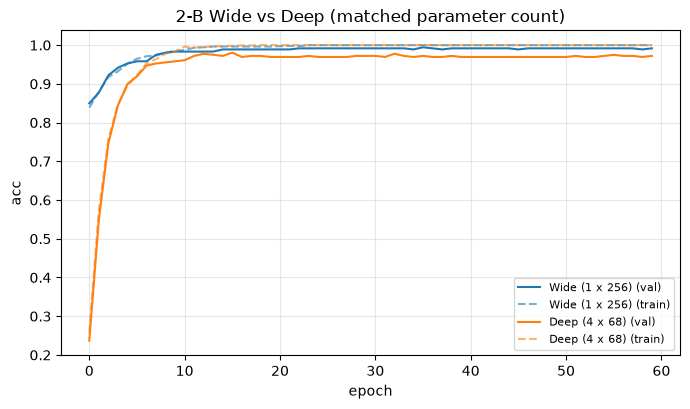


[여러 시드에서 반복]
  seed=0      wide=0.9778  deep=0.9472
  seed=1      wide=0.9778  deep=0.9639
  seed=42     wide=0.9750  deep=0.9611
  seed=2288   wide=0.9722  deep=0.9722
  seed=7777   wide=0.9722  deep=0.9611

Wide 평균 = 0.9750 (표준편차 0.0025)
Deep 평균 = 0.9611 (표준편차 0.0081)
Wide 가 이긴 횟수: 4 / 5


In [12]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 68
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.
: h는 68을 사용하였고 Deep의 파라미터 수는 19186개이다. Wide와는 0.12%(24개) 차이가 난다. 본 실험에서는 깊이를 비교하는 것이 목적이므로 깊이 이외의 요소들은 최대한 비슷하게 맞춰야 한다. 따라서 파라미터 수도 맞춰야 공정한 비교가 될 수 있다.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**
: Wide의 test_acc는 0.9722 , Deep의 test_acc는 0.9722로 동일하게 나왔다. 본 실험에서는 test_acc에서 Deep이 더 높은 성능을 보인다는 결론이 재현되지 않았다.

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?
: Wide 평균 = 0.9750 (표준편차 0.0025), Deep 평균 = 0.9611 (표준편차 0.0081) 이고 Wide가 이긴 횟수는 5번중 4번이다. 5번의 반복에서 4번 모두 Wide의 성능이 더 높게 나타났는데 출력된 결과에서만 성능이 동일하게 나왔었다. 5개 시드 결과는 Wide의 성능이 더 좋다.

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다

-> (a), (b)
(a)
: 두 모델 모두 파라미터가 19000개인 것에 비해 훈련 샘플은 1078개로 데이터가 너무 작다. Deep 모델의 final train_loss가 0.0004까지 내려갔음에도 Deep의 평균 test_acc는 0.9611에 그치는 것을 보아 Deep 구조의 높은 표현력을 충분히 활용하지 못했다.
(b)
: 8x8 digits 데이터는 이미지 입력으로는 매우 작은 편이며 각 이미지 숫자를 구분하는데 필요한 패턴도 비교적으로 단순한 편이다. Deep network의 장점은 여러 층을 통해 저수준 특징(선, 모서리 등)을 조합하여 고수준의 계층적 특징(배경, 질감 등)을 표현하는 데 있지만 본 데이터에서는 이러한 복잡한 계층 구조가 크게 필요하지 않아 보인다. 실제 실험에서도 파라미터수를 비슷하게 맞춘 Wide 모델의 평균 test_acc가 0.9750으로 Deep 모델 보다 높았으므로 깊이를 깊게 하는 것보다 한 층을 넓게 사용하는 것만으로도 표현력을 충분히 확보했을 가능성이 있다.

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.
: 입력 데이터가 많고 복잡하며 계층적인 특징을 학습해야 하는 문제에서는, 적절한 구조를 가진 Deep 네트워크가 Wide 네트워크보다 파라미터를 더 효율적으로 사용하여 높은 성능을 낼 수 있다. CNN 기반 이미지 인식인 컴퓨터 비전 사례에서는 저수준의 edge와 질감부터 물체의 부분, 전체 객체까지 계층적인 특징을 학습해야 하므로, Deep 모델이 이러한 표현을 단계적으로 구성할 수 있어 Wide 모델보다 훨씬 유리하다. 

In [37]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)


# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))
# ____

#B보다 L2 강도를 조금 높이면 과적합을 더 효과적으로 억제하여 validation 성능이 향상될 것이다.
try_config("C. Wide + L2 wd=1e-3", hidden=(256,), wd=1e-3)

#L2 규제를 더 강하게 적용하면 일반화 성능이 더욱 향상될 수 있다.
try_config("C_1. Wide + L2 wd=1e-2", hidden=(256,), wd=1e-2)

# Wide 모델의 폭을 512까지 늘리면 표현력이 증가하여 성능이 향상될 수 있으며, 증가한 모델 복잡성은 L2 규제가 보완해 줄 것이다
try_config("D. Wide_512 + L2 wd=1e-2", hidden=(512,), wd=1e-2)

# Wide(512) 구조에서는 너무 강한 L2보다 적당한 L2(1e-3)가 표현력과 일반화의 균형을 이루어 더 좋은 성능을 낼 것이다.
try_config("D_1. Wide_512 + L2 wd=1e-3", hidden=(512,), wd=1e-3)

# 은닉층 폭을 더욱 크게(1028) 하면 더 많은 특징을 학습하여 validation 성능이 향상될 것이다.
try_config("D_2. Wide_1028 + L2 wd=1e-3", hidden=(1028,), wd=1e-3)

# L2와 Dropout을 함께 적용하면 과적합을 더욱 효과적으로 억제하여 일반화 성능이 향상될 것이다.
try_config("F. Wide_512 + Dropout 0.5 + L2", hidden=(512,), p_drop=0.5, wd=1e-4)

# Dropout 비율을 더 높이면 과적합을 더 강하게 억제하여 validation 성능이 향상될 수 있다. 다만 너무 높은 Dropout은 학습을 방해할 가능성도 있다.
try_config("F_1. Wide_512 + Dropout 0.7 + L2", hidden=(512,), p_drop=0.7, wd=1e-4)

# 앞에서 Momentum이 빠르게 수렴하는 모습을 보였으므로, 높은 learning rate에서도 빠르게 최적점에 도달하여 높은 validation 성능을 보일 것이다.
try_config("G. Wide_512 + Momentum", hidden=(512,), wd=1e-3, opt_name="momentum", lr=0.5)

# G에서 learning rate가 너무 커 성능이 저하된다면, learning rate를 0.1로 낮추면 보다 안정적으로 학습되어 validation 성능이 향상될 것이다.
try_config("G_1. Wide_512 + Momentum", hidden=(512,), wd=1e-3, opt_name="momentum", lr=0.1)

# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 1e-3
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 75

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

print(*log, sep="\n")

A. baseline 재현 (64,32)                 best_val_acc=0.9889  (val_loss 최저 ep=79, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9944  (val_loss 최저 ep=79, params=19210)
C. Wide + L2 wd=1e-3                   best_val_acc=0.9944  (val_loss 최저 ep=75, params=19210)
C_1. Wide + L2 wd=1e-2                 best_val_acc=0.9889  (val_loss 최저 ep=58, params=19210)
D. Wide_512 + L2 wd=1e-2               best_val_acc=0.9916  (val_loss 최저 ep=58, params=38410)
D_1. Wide_512 + L2 wd=1e-3             best_val_acc=0.9916  (val_loss 최저 ep=75, params=38410)
D_2. Wide_1028 + L2 wd=1e-3            best_val_acc=0.9916  (val_loss 최저 ep=75, params=77110)
F. Wide_512 + Dropout 0.5 + L2         best_val_acc=0.9916  (val_loss 최저 ep=75, params=38410)
F_1. Wide_512 + Dropout 0.7 + L2       best_val_acc=0.9944  (val_loss 최저 ep=78, params=38410)
G. Wide_512 + Momentum                 best_val_acc=0.9526  (val_loss 최저 ep=1, params=38410)
G_1. Wide_512 + Momentum               best_val_acc=0.9889  (v

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.
:
A. baseline 재현 (64,32)                 best_val_acc=0.9889  (val_loss 최저 ep=79, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9944  (val_loss 최저 ep=79, params=19210)
C. Wide + L2 wd=1e-3                   best_val_acc=0.9944  (val_loss 최저 ep=75, params=19210)
C_1. Wide + L2 wd=1e-2                 best_val_acc=0.9889  (val_loss 최저 ep=58, params=19210)
D. Wide_512 + L2 wd=1e-2               best_val_acc=0.9916  (val_loss 최저 ep=58, params=38410)
D_1. Wide_512 + L2 wd=1e-3             best_val_acc=0.9916  (val_loss 최저 ep=75, params=38410)
D_2. Wide_1028 + L2 wd=1e-3            best_val_acc=0.9916  (val_loss 최저 ep=75, params=77110)
F. Wide_512 + Dropout 0.5 + L2         best_val_acc=0.9916  (val_loss 최저 ep=75, params=38410)
F_1. Wide_512 + Dropout 0.7 + L2       best_val_acc=0.9944  (val_loss 최저 ep=78, params=38410)
G. Wide_512 + Momentum                 best_val_acc=0.9526  (val_loss 최저 ep=1, params=38410)
G_1. Wide_512 + Momentum               best_val_acc=0.9889  (val_loss 최저 ep=75, params=38410)

======================================================================
실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
B. Wide + 약한 L2                                 0.9944       79   19210
C. Wide + L2 wd=1e-3                            0.9944       75   19210
F_1. Wide_512 + Dropout 0.7 + L2                0.9944       78   38410
D. Wide_512 + L2 wd=1e-2                        0.9916       58   38410
D_1. Wide_512 + L2 wd=1e-3                      0.9916       75   38410
D_2. Wide_1028 + L2 wd=1e-3                     0.9916       75   77110
F. Wide_512 + Dropout 0.5 + L2                  0.9916       75   38410
A. baseline 재현 (64,32)                          0.9889       79    6570
C_1. Wide + L2 wd=1e-2                          0.9889       58   19210
G_1. Wide_512 + Momentum                        0.9889       75   38410
G. Wide_512 + Momentum                          0.9526        1   38410

======================================================================
[최종 모델] val 최고 = 0.9944
[최종 모델] TEST accuracy = 0.9778  (baseline 대비 +0.0028)
======================================================================
('A. baseline 재현 (64,32)', 0.9888579249382019, 79, 6570)
('B. Wide + 약한 L2', 0.9944289922714233, 79, 19210)
('C. Wide + L2 wd=1e-3', 0.9944289922714233, 75, 19210)
('C_1. Wide + L2 wd=1e-2', 0.9888579249382019, 58, 19210)
('D. Wide_512 + L2 wd=1e-2', 0.9916434288024902, 58, 38410)
('D_1. Wide_512 + L2 wd=1e-3', 0.9916434288024902, 75, 38410)
('D_2. Wide_1028 + L2 wd=1e-3', 0.9916434288024902, 75, 77110)
('F. Wide_512 + Dropout 0.5 + L2', 0.9916434288024902, 75, 38410)
('F_1. Wide_512 + Dropout 0.7 + L2', 0.9944289922714233, 78, 38410)
('G. Wide_512 + Momentum', 0.9526462554931641, 1, 38410)
('G_1. Wide_512 + Momentum', 0.9888579249382019, 75, 38410)

**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "____ 하면 ____ 할 것이다. 왜냐하면 §__ 에서 ____ 를 봤기 때문이다."
- 결과: val accuracy ____ → ____
- 판정 및 해석: ____

(2)-1 가설이 맞았던 것
- 가설: "Wide 모델에 L2와 Dropout 0.7을함께 적용하면 과적합을 더 효과적으로 억제하여 validation 성능이 향상될 것이다. 왜냐하면 §1.4에서 L2와 Dropout이 모두 과적합을 완화하는 규제 방법임을 확인했기 때문이다."
- 결과: val accuracy 0.9916 → 0.9944
- 판정 및 해석: 가설과 일치하였다. Dropout 비율을 0.5에서 0.7로 높였을 때 val accuracy가 상승했으므로, 이 실험에서는 더 강한 Dropout이 일반화 성능 향상에 도움이 된 것으로 볼 수 있다.

(2)-2 가설이 틀렸던 것
- 가설: "L2 규제를 강하게 하면 validation 성능이 더 좋아질 것이다. 왜냐하면 §1.4 에서 L2 규제가 과적합을 줄이는 효과를 봤기 때문이다."
- 결과: val accuracy 0.9944 → 0.9889
- 판정 및 해석: 가설과 일치하지 않았다. L2 규제를 너무 강하게 적용하면서 가중치 학습이 과도하게 제한되어 오히려 성능이 감소한 것으로 해석할 수 있다.


**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.
: validation 성능이 최고 수준이면서 모델 복잡도까지 고려했을 때 가장 효율적이기 때문이다. 먼저 val accuracy만 보면 최고값은 0.9944였고, 파라미터의 수도 같은 val accuracy 수준의 다른 모델에 비해 절반 정도 밖에 되지 않아 모델 효율성 측면에서 더 적합하다고 판단하였다. 또한 동일한 val accuracy의 타 모델에 비해 조금 더 이른 시점에 validation loss가 최소가 되었기 때문에 최종 모델로 선택하였다.

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)
: best val accuracy는  0.9944이고 test accuracy는 0.9778이고 best val accuracy가 더 높다. 파라미터를 조정할때 val 데이터를 이용하여 val 성능이 가장 좋은 모델을 선택했으므로 val 성능이 test에 비해 더 높게 평가될 수 있다. 반면 test 데이터는 모델 선택 과정에 전혀 사용되지 않은 새로운 데이터이므로 일반화 성능을 보다 객관적으로 평가한 결과라고 볼 수 있다.

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
: test 데이터를 여러번 보면서 하이퍼파라미터를 튜닝했다면, 모델이 test데이터의 특성까지 학습하게 되어 test accuracy가 실제 일반화 성능보다 더 높게 평가될 수 있다. 더이상 test 데이터는 새로운 데이터가 아니므로 과대평가 하게 된다. 원래 모델 학습 및 파라미터 튜닝 과정에서는 알 수 없어야하는 test 데이터의 정보를 모델 선택에 사용하게 되므로 미래 데이터를 미리 본 것과 같은 상황이 되어 데이터 누수가 발생하게 되고 일반화 성능을 객관적으로 평가할 수 없게 된다.

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → (여기에 답)
:파라미터 수는 6570개였고, test accuracy는 0.9750이었다. train/val loss 곡선에서 Early Stopping이 필요해 보인 시점은 15~20 epoch 부근으로 볼 수 있을 것 같다. 이유는 해당 시점부터 곡선이 거의 평평해지고, train/val loss간의 격차가 점점 벌어지기 시작하기 때문에 그전에 early stopping을 하는 것이 좋을 것 같다.

- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm 1.57e-07 vs 마지막 층 3.55e-01. 이 차이가 train accuracy 0.1957로 이어진 인과를 한 문장으로: (여기에 답)
: 앞쪽층의 가중치가 거의 업데이트되지 않아 vanishing gradient가 발생하고 이로 인해 학습자체가 잘 되지 않아 train accuracy가 낮게 나왔다.

- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = 0.2030, Early Stopping 시점 = epoch 20. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: (여기에 답)
: Dropout p=0.5가 가장 최선이었다. baseline 조건에서 모델은 train 데이터에 대한 정확도는 높으나 val_acc가 상대적으로 떨어져 과적합으로 볼 수 있다. dropout의 경우 train loss도 줄어들고, val_acc는 증가하였으며 과적합이 완화되고 성능도 더 개선되었다. L2 규제의 경우 train loss가 심하게 증가하였으며 val_acc가 떨어지거나 변화가 없었고, train_acc도 떨어지는 경우가 있었기 때문에 `Dropout p=0.5`가 가장 최선으로 보여진다.

- **Optimization (§1.5):** val 90% 도달 epoch — SGD 14 / Momentum 3 / Adam 7. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: (여기에 답)
: 수렴 속도는 얼마나 빨리 좋은 성능에 도달했는가를 의미하고, 최종 성능은 충분히 학습한 후 얼마나 높은 성능에 도달했는가를 의미하기 때문에 수렴 속도가 빠르다고 해서 반드시 최종 성능도 가장 좋은 것은 아니며 반대로 수렴 속도가 느리더라도 더 높은 최종 성능을 얻을 수도 있다.

- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 1.907e-05가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? (여기에 답)
: 활성화 함수가 없다면 층을 아무리 많이 쌓더라도 1개의 층을 쌓은것과 결과가 유사하다는 것을 증명하였다.

: Wide가 이겼고, 강의 슬라이드와 그 결과가 다른 이유는 파라미터 개수에 비해 훈렴 샘플수가 너무 적었고, 8x8 digits 데이터는 이미지 입력으로는 매우 작고 패턴이 비교적 단순하여 복잡한(Deep) 계층 구조가 크게 필요하지 않았기 때문이다.

- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: (여기에 답)
: 강의에서는 일반적으로 Deep 모델이 더 높은 성능을 낼 수 있다고 설명했지만 입력이 단순한 이미지이고 훈련샘플이 적은 경우에는 Wide 모델이 더 높은 val 성능을 보였다. 이를 통해 모델의 성능은 일반론만으로 결정되는 것이 아니라 데이터의 특성과 문제의 난이도에 따라 적합한 모델이 달라질 수 있다는 점을 배웠다.

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: (여기에 답)
: 이번 과제에서 가장 헷갈렸던 개념은 L2 규제와 Dropout의 차이였다. 처음에는 두 방법 모두 과적합을 줄이는 기법이라는 점만 알고 있었지만, 실습과제를 하면서 L2는 가중치의 크기를 제한하는 규제이고, Dropout은 학습 과정에서 일부 뉴런을 비활성화하여 다양한 모델을 학습하는 효과를 준다는 차이를 이해하게 되었다.

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)
: 문법 질문, 답안 검토

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

  : 없음

- **실제 대화 내역** 붙여넣기:

```
그럼 코드 돌릴때마다 log는 초기화되는거임? 그냥 한번 돌려서 나오는 맨 위의 결과랑 log랑 똑같음. 이전에 돌렸던게 저장이안되는걵가?

네, 초기화됩니다. 지금 네가 본 현상이 정상이에요.

코드를 보면 맨 위에

log = []

가 있죠.

이 셀을 다시 실행하는 순간

log = []

가 다시 실행되면서

기존에 있던 내용은 모두 사라지고 빈 리스트로 초기화됩니다.

그 다음

try_config("A", ...)
try_config("B", ...)

만 실행했으면

log에는

A
B

만 들어갑니다.

예를 들어

처음에

log = []

try_config("A")
try_config("B")

를 실행하면

print(log)

↓

[A, B]

입니다.

그런데 다시 위 셀을 실행하면

log = []

가 실행되므로

기존

[A, B]

가 없어집니다.

그 후

try_config("C")

만 실행하면

[C]

만 남습니다.

그래서 과제에서 말하는 "모든 실험"은

이번 2-C를 수행하면서 시도한 모든 실험을 말합니다.

예를 들어

try_config("A")
try_config("B")
try_config("C")
try_config("D")
try_config("E")

를 한 번의 실행에서 다 돌리면

A
B
C
D
E

가 모두 log에 남습니다.

하지만

예전에 했던

1.2
1.4
1.5
2-B

실험 결과까지 자동으로 저장되는 건 아닙니다.

그건 애초에 log를 사용하지 않았기 때문입니다.

만약 "이전까지 했던 모든 실험"을 저장하려면?

그건 log를 처음부터 계속 사용했어야 합니다.

예를 들어 1.4에서도

log.append(...)

1.5에서도

log.append(...)

2-B에서도

log.append(...)

이렇게 작성했어야

마지막에

1.2 Baseline
1.4 Dropout
1.4 L2
1.5 Adam
2-B Wide
2-B Deep
...

처럼 전부 남습니다.

결론

네가 본

"log가 그냥 이번에 돌린 결과랑 똑같은데?"

라는 건 정상입니다.

이 과제에서의 log는

2-C에서 여러 하이퍼파라미터를 시도한 기록

을 남기라는 의미이지,

지금까지 과제 전체에서 했던 모든 실험

을 저장하는 용도는 아닙니다.
```

```
거의 맞는데, 과제 의도에 따라 조금 다릅니다.

현재 코드대로라면

FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 1e-3
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 80

도 코드는 정상적으로 동작합니다. 왜냐하면 try_config()에서 C를 실행할 때도 80 epoch로 학습했기 때문입니다.

하지만 문제 설명을 보면

Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)

을 힌트로 주고 있고, C의 결과가

C. Wide + L2 wd=1e-3
best_val_acc = 0.9944
(val_loss 최저 ep = 75)

였죠.

그래서 과제 취지에 더 맞게 작성하려면

FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 1e-3
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 75

가 더 적절합니다.

왜 75가 더 좋은가?

80 epoch까지 학습하면 마지막 5 epoch는 이미 validation loss가 다시 나빠지는 구간일 수도 있습니다.

즉,

75 epoch: validation loss 최소 (가장 일반화가 잘 되는 시점)
80 epoch: 조금 더 학습해서 train은 더 좋아질 수 있지만 validation은 오히려 나빠질 수 있음

그래서 Early Stopping에서는 75 epoch에서 멈추는 것이 원칙입니다.

그런데 한 가지 주의할 점

지금 코드의

final_model = build_mlp(...)
final_hist = train_model(final_model, epochs=FINAL_EPOCHS, ...)

는 75 epoch까지만 새로 학습하는 것이지,

75 epoch에서 저장했던 가중치를 복원하는 것은 아닙니다.

엄밀한 Early Stopping은

80 epoch까지 학습
75 epoch에서의 state_dict 저장
마지막에 그 가중치를 다시 불러오기

입니다.

하지만 현재 과제 코드에서는 그 기능을 구현하지 않았기 때문에, FINAL_EPOCHS = 75로 두는 것이 Early Stopping을 가장 잘 반영한 설정이라고 보면 됩니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (여기에 답)
: 성능이 비슷하거나 trade-off가 존재하는 경우 최적의 최종 선택하는 것은 AI가 대신할 수 없고 나만의 판단에 해당한다.
